In [24]:
import mlflow
from mlflow.tracking import MlflowClient
import pandas as pd

mlflow.set_tracking_uri("http://localhost:5000") 

client = MlflowClient()

# Search for runs within a specific experiment
runs = client.search_experiments(filter_string="name = 'ESP32_Optuna_Tuning'")
experiment = runs[0]
print('Experiments found: ', len(runs))
for experiment in runs:
    print(f"Experiment ID: {experiment.experiment_id}, Name: {experiment.name}")

print("\nDetailed runs in the experiment:")
# List all runs in the experiment
experiment_id = experiment.experiment_id
RUN_NAME = "Optuna_Session_v3_Reward_Tuning"
filter = f'tags.`git.branch` ="exp/reward-tuning" and attributes.run_name != "{RUN_NAME}"'
all_runs = client.search_runs(experiment_ids=[experiment_id], filter_string=filter)

for run in all_runs[:10]:
    print(f"Run ID: {run.info.run_id}, ParentId: {run.data.tags.get('mlflow.parentRunId', 'N/A')}, Name: {run.data.tags.get('mlflow.runName', 'N/A')}, Metrics: {run.data.metrics}, Params: {run.data.params}")



data = [{   **run.data.metrics,
            **run.data.params,
            'run_id': run.info.run_id,
            'parent_run_id': run.data.tags.get('mlflow.parentRunId', None),
            'run_name': run.data.tags.get('mlflow.runName', None),
            'batch_size': int(run.data.params.get('batch_size', 0)),
            'epsilon': float(run.data.metrics.get('epsilon', 0.0)),
            'learning_rate': float(run.data.params.get('learning_rate', 0.0)),
            'max_steps': int(run.data.params.get('max_steps', 0)),
            'episodes': int(run.data.params.get('episodes', 0)),
            'epsilon_decay': float(run.data.params.get('epsilon_decay', 0.0)),
        } 
for run in all_runs]

df = pd.DataFrame(data)
print("\nDataFrame of runs:")
print(df.describe())


Experiments found:  1
Experiment ID: 787176341010319053, Name: ESP32_Optuna_Tuning

Detailed runs in the experiment:
Run ID: 7260a2dd7b74480a828f77e30241f59e, ParentId: ad6e1b02c4834d1bac2755b8dcae7c7e, Name: opt_reward_tuning_trial_029, Metrics: {'avg_distance': 2.0150075451926006, 'avg_loss': 0.03738579642027617, 'crash_rate': 0.0, 'epsilon': 0.4853099615909642, 'fail_reason': 0.0, 'final_dist': 1.2228245404256481, 'final_idle': 0.43573333333333336, 'idle_ratio': 0.348, 'optuna_score': 2.9047280909878523, 'reward': 1.956655663502754}, Params: {'architecture': 'DQN_3_64_64_5', 'batch_size': '128', 'episodes': '30', 'epsilon_decay': '0.9761891437322582', 'learning_rate': '0.001507213594877458', 'max_steps': '250'}
Run ID: 1514b5a8bf744d349b0e1160f787ac07, ParentId: ad6e1b02c4834d1bac2755b8dcae7c7e, Name: opt_reward_tuning_trial_028, Metrics: {'avg_distance': 0.8703720203927354, 'avg_loss': 0.02622113971867495, 'crash_rate': 0.005, 'epsilon': 0.3484986571227281, 'fail_reason': 0.0, 'fin

In [49]:
df['optuna_score'].describe()

count    30.000000
mean      5.616540
std       6.196639
min     -10.676541
25%       3.188456
50%       6.802490
75%       8.983351
max      16.902735
Name: optuna_score, dtype: float64

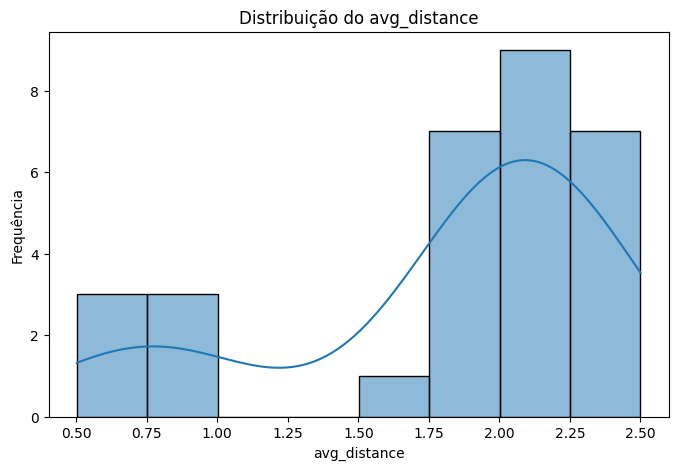

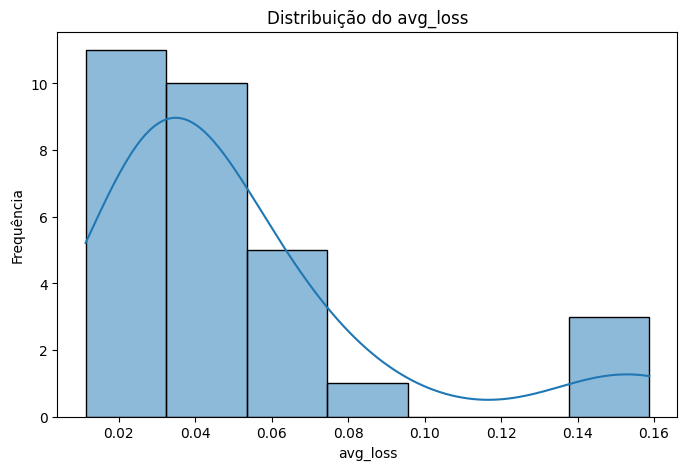

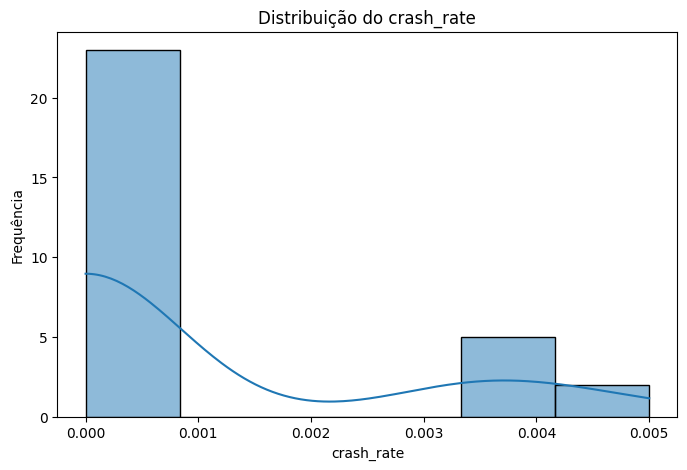

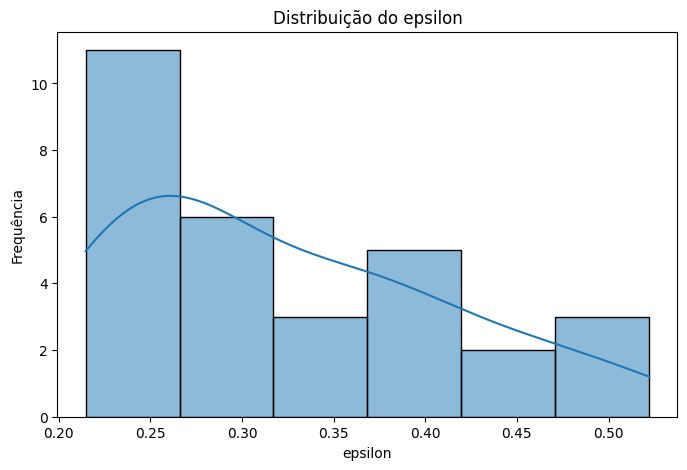

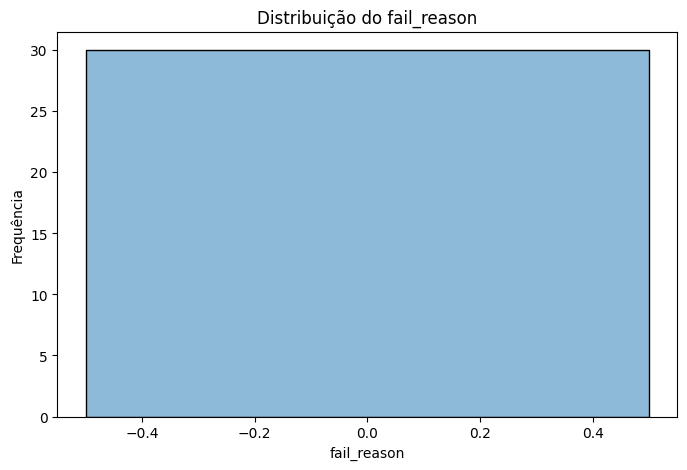

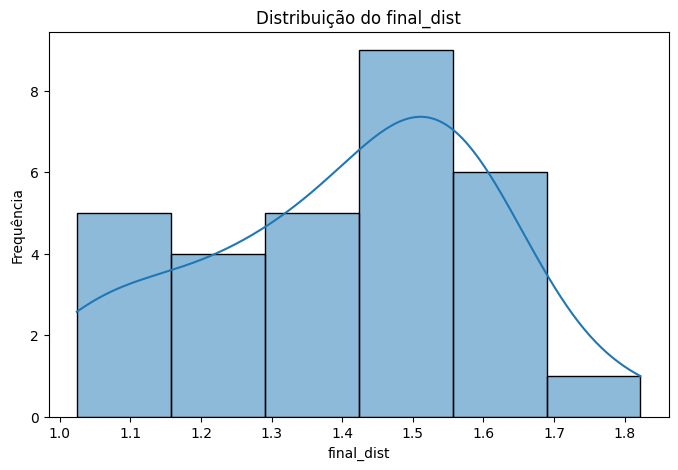

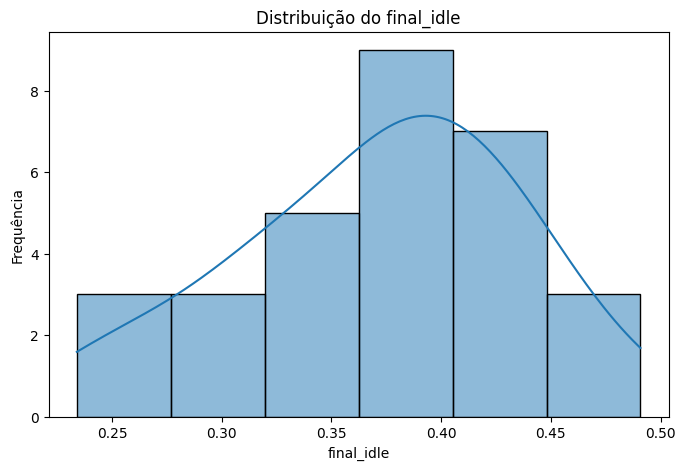

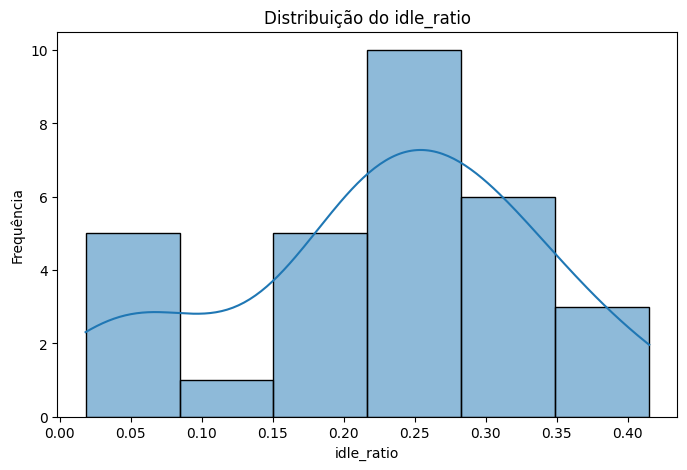

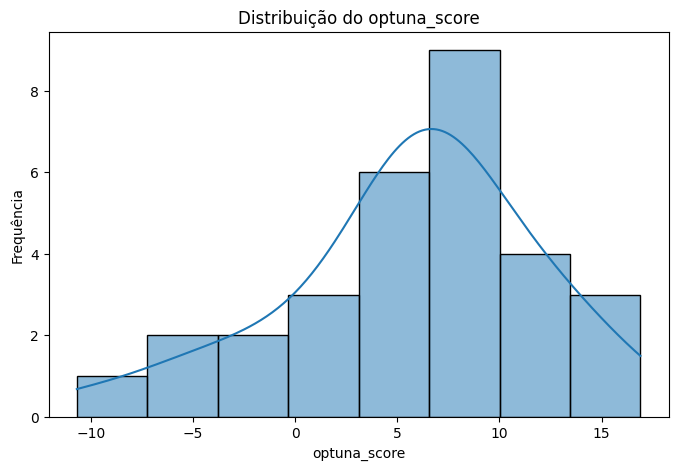

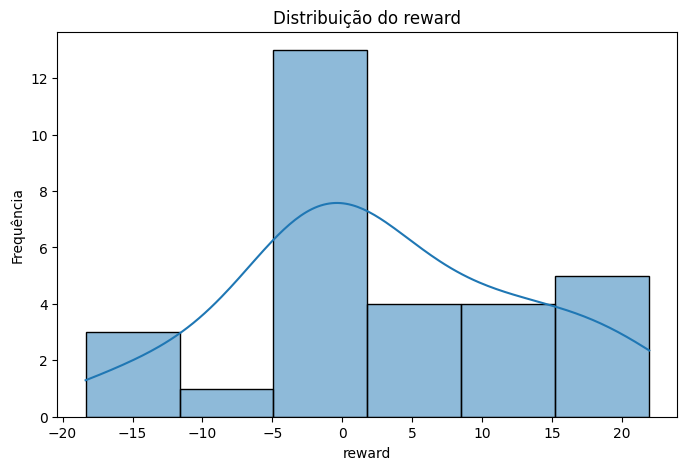

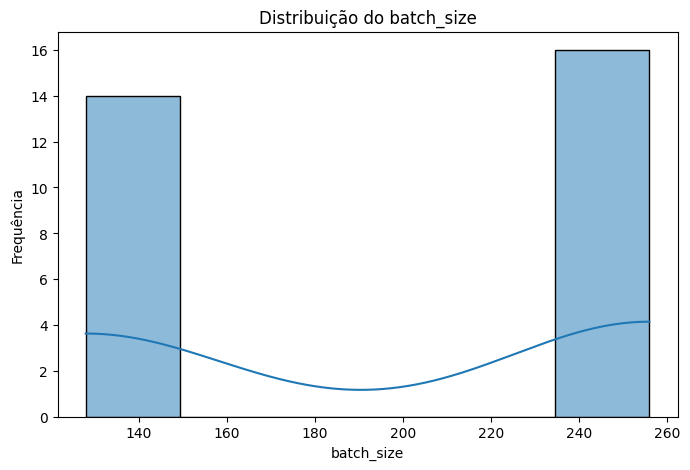

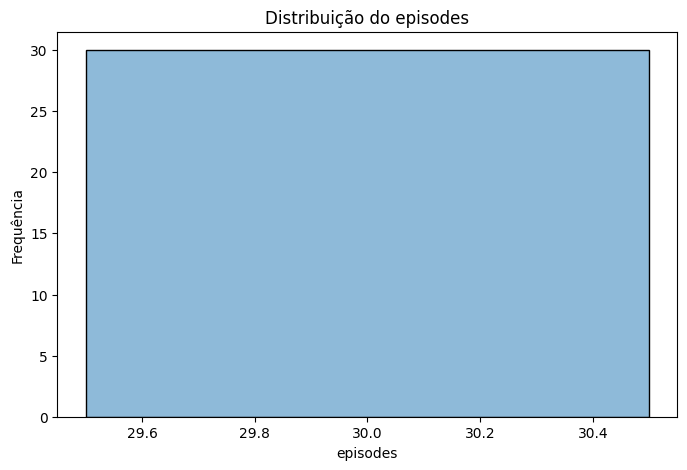

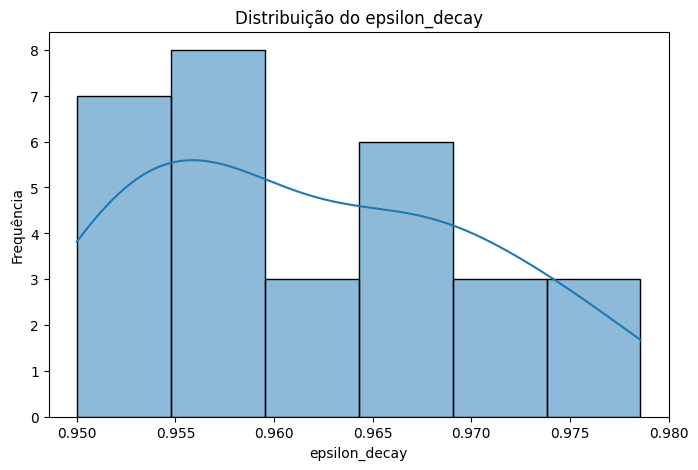

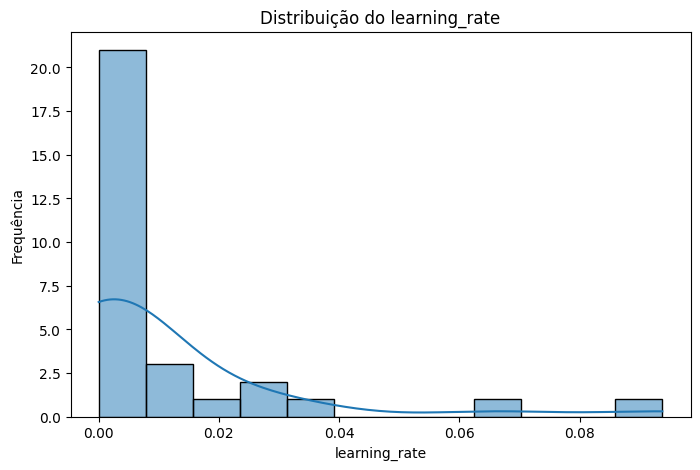

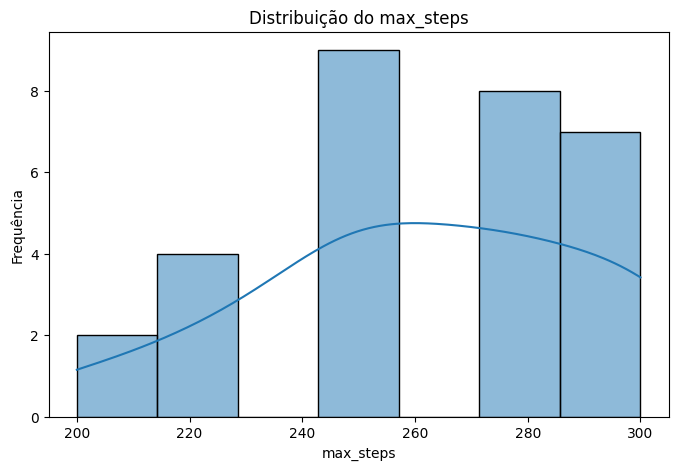

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt


def show_histogram(column_name):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column_name], kde=True) # kde=True adiciona uma linha de densidade
    plt.title(f'Distribuição do {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequência')

for column in df.select_dtypes(include=['float64', 'int64']).columns:
    show_histogram(column)

plt.show()


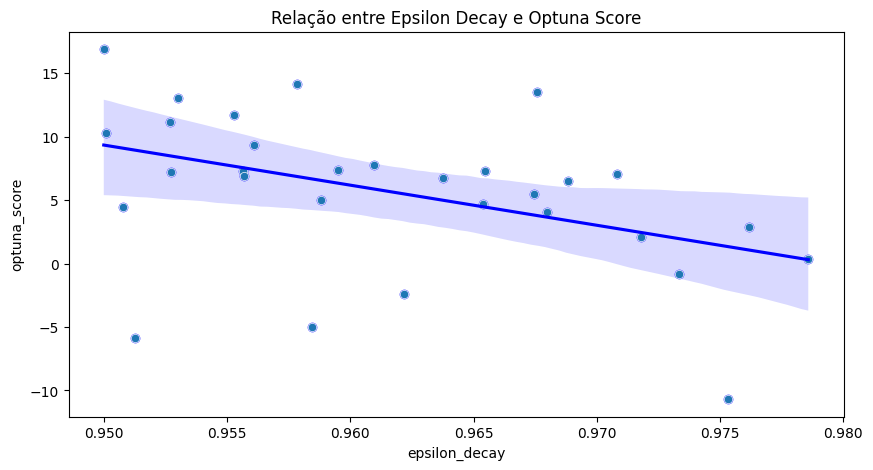

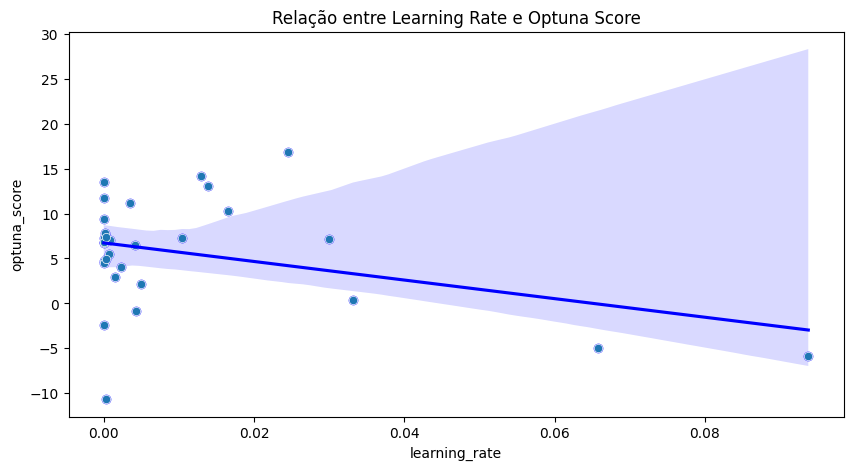

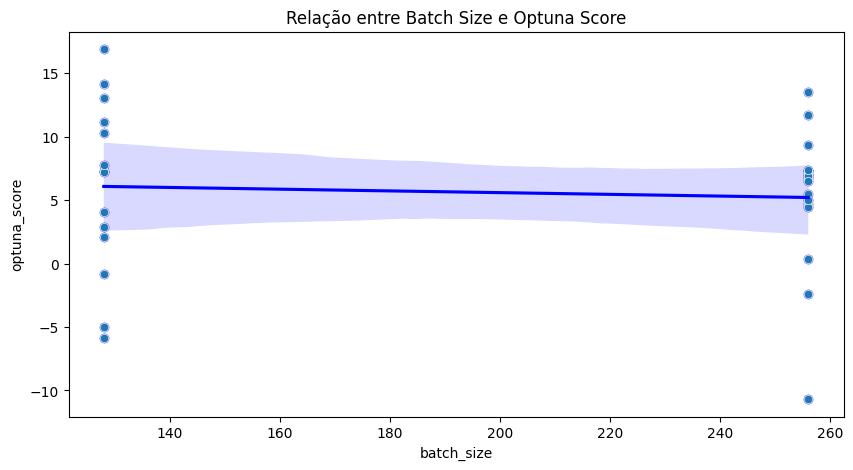

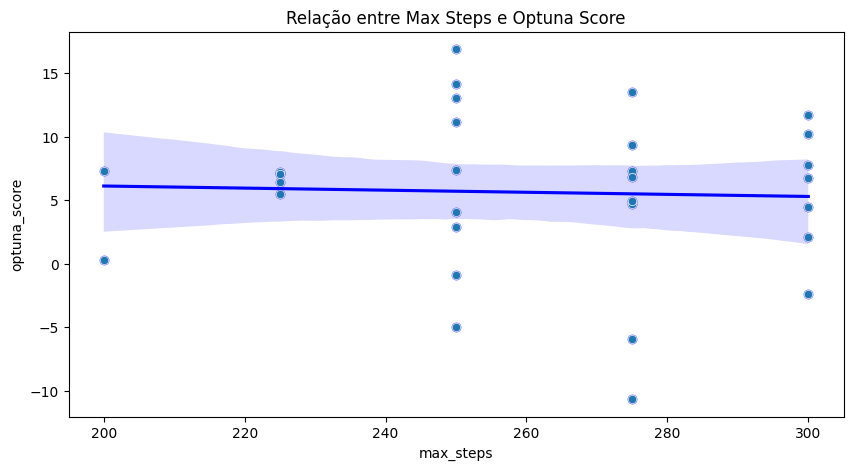

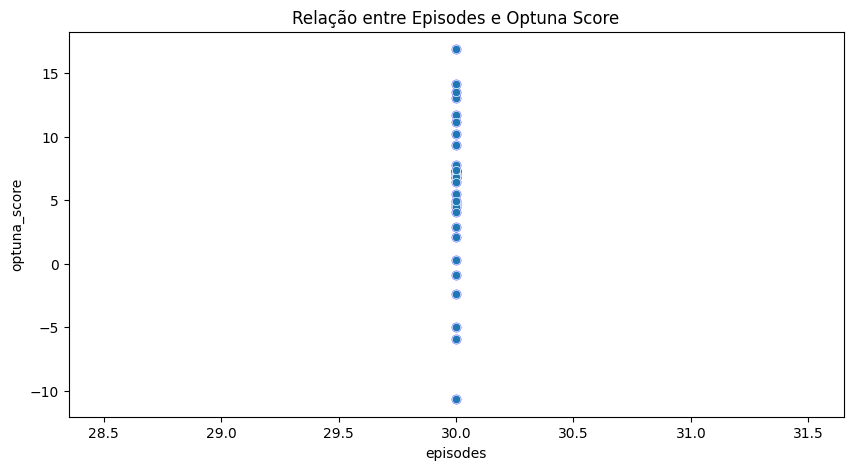

In [46]:
# Exemplo: Existe relação entre o parâmetro epsilon e o resultado final (optuna_score)?
metrics = ['optuna_score', 'avg_distance', 'avg_loss', 'crash_rate', 'epsilon', 'fail_reason', 'reward']
params = ['epsilon_decay', 'learning_rate', 'batch_size', 'max_steps', 'episodes']

def _to_pascal_case(snake_str):
    components = snake_str.split('_')
    return ' '.join(x.title() for x in components)

def show_correlation(x, y):
    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=x, y=y, data=df, zorder=2)
    sns.regplot(x=x, y=y, data=df, color='blue')
    plt.title(f'Relação entre {_to_pascal_case(x)} e {_to_pascal_case(y)}')
    plt.xlabel(x)
    plt.ylabel(y)

for param in params:
    show_correlation(param, 'optuna_score')
plt.show()



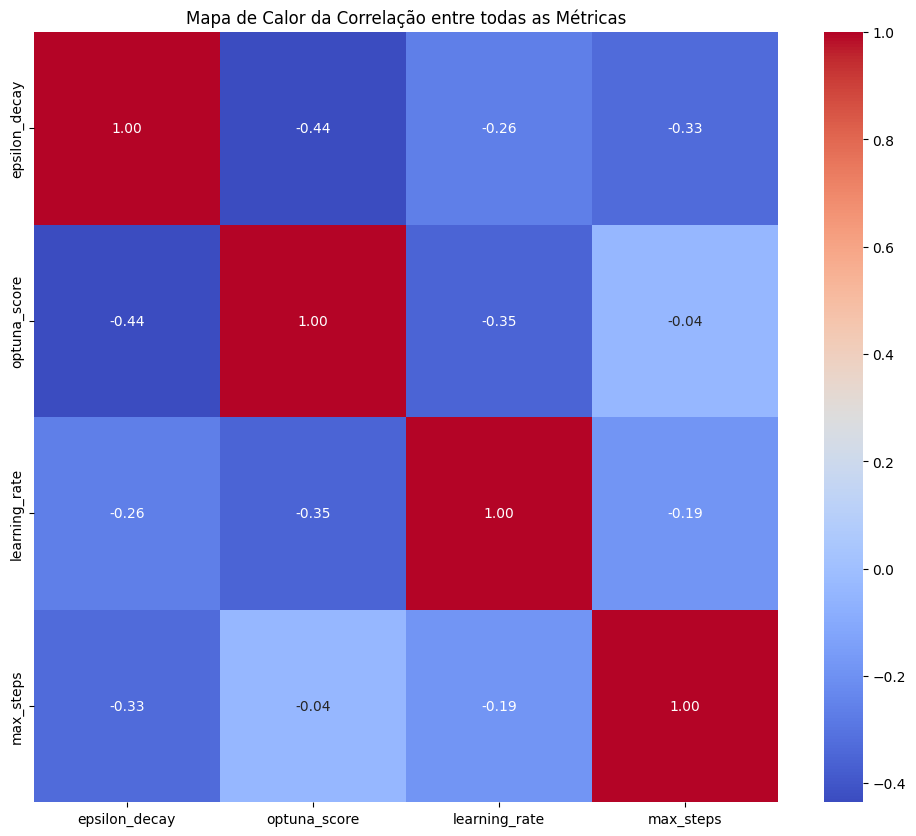

In [48]:
temp = df.drop(columns=['run_id', 'parent_run_id', 'run_name', 'architecture'])
correlation_matrix = temp[['epsilon_decay', 'optuna_score','learning_rate', 'max_steps']].corr()
plt.figure(figsize=(12, 10))
# Usamos annot=True para mostrar o valor da correlação dentro do quadrado
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor da Correlação entre todas as Métricas')
plt.show()